In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from typing import *

import cv2
import numpy as np
import ray
from ray import serve

from utils.gui import vis, vbbox, vic
from visual.models.diagram import BBox, DiagramNode

In [3]:
ray.init()

2026-03-17 22:28:18,044	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 192.168.0.88:6379...
2026-03-17 22:28:18,065	INFO worker.py:2004 -- Connected to Ray cluster. View the dashboard at http://127.0.0.1:8265 
/home/petr/study/diploma/.venv/lib/python3.12/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Python version:,3.12.11
Ray version:,2.54.0
Dashboard:,http://127.0.0.1:8265


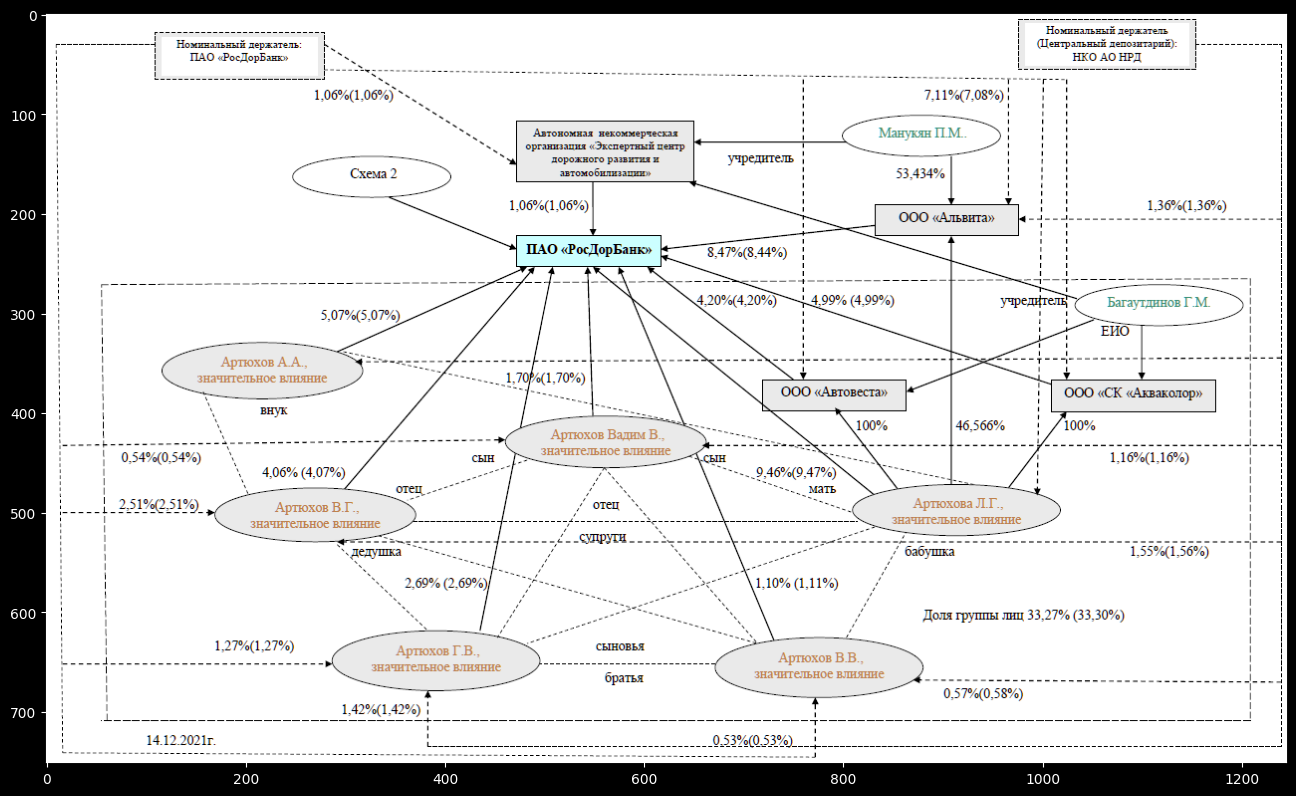

In [4]:
from utils.gui import stack_images

tests = {
    # "ed36a1594d570e76e0219bda981adb6c",
    # "/home/petr/study/diploma/src/datasetgen/full/f8e3fa2523fff97a2dc9c382dcb3b634.png",
    "/home/petr/study/diploma/src/datasetgen/demo/6.png",
    # "/home/petr/Documents/1.png",
    # "ec5ce1afe4d3c3d4c13470842eee7e5f"
}

orig = stack_images([
    cv2.imread(f"{i}")
    for i in tests
], 1, 1)
vis(orig)

In [7]:
# ocr = serve.get_deployment_handle("OCRReaderYandex", app_name="default")
ocr = serve.get_deployment_handle("OCRReaderEasyocr", app_name="ocr")

ocr_data = await ocr.remote(orig, dict(
    slope_ths=0.1,
    ycenter_ths=0.5,  # max shift y
    height_ths=0.4,  # max box height diff
    width_ths=0.5,  # max horizontal distance
    add_margin=0,
    x_ths=0.5,
    y_ths=0.5,
    paragraph=False
))
ocr_boxes, ocr_texts = ocr_data.boxes

# vis(vbbox(orig, ocr_boxes))

(ServeReplica:ocr:OCRReaderEasyocr pid=620363) [OCR] start


In [8]:
from visual.analyze.detection.model import DetectorObjectType
from shapely import Point, Polygon
from visual.analyze.structure.node import ImageGraphNode

dnd = serve.get_deployment_handle("DiagramNodesDetector", app_name="det")
bbs = await dnd.remote(orig)

nodes: List[ImageGraphNode] = []
arrowheads: List[Point] = []

for i in bbs:
    bb_poly: Polygon = i.bbox.polygon()
    if i.type == DetectorObjectType.NODE:
        nodes.append(ImageGraphNode(box=bb_poly))
    elif i.type == DetectorObjectType.ARROWHEAD:
        arrowheads.append(bb_poly.centroid)

node_bboxes = [i.bbox for i in bbs]
# vis(vbbox(orig, node_bboxes))

(ServeReplica:det:DiagramNodesDetector pid=620357) [YOLO-DIAG] Running
(ServeReplica:det:DiagramNodesDetector pid=620357) 
(ServeReplica:ocr:OCRReaderEasyocr pid=620363) [OCR] done #71 time 564ms


(ServeReplica:ocr:OCRReaderEasyocr pid=620363) INFO 2026-03-17 22:28:48,630 ocr_OCRReaderEasyocr n6kpvkc5 215ca6d1-49a4-4a3b-826f-3695d99c0f70 -- CALL __call__ OK 565.5ms


(ServeReplica:det:DiagramNodesDetector pid=620357) 0: 416x640 16 nodes, 38 arrowheads, 199.8ms
(ServeReplica:det:DiagramNodesDetector pid=620357) Speed: 1.1ms preprocess, 199.8ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 640)
(ServeReplica:det:DiagramNodesDetector pid=620357) [YOLO-DIAG] Detections: dict_items([(NODE, 16), (ARROWHEAD, 33)])


(ServeReplica:det:DiagramNodesDetector pid=620357) INFO 2026-03-17 22:28:48,868 det_DiagramNodesDetector tllt1otj 32273e03-91d0-4603-af7d-c1fef95cd070 -- CALL __call__ OK 203.7ms


In [10]:
def bboxes2mask(bboxes: List[BBox], shape):
    mask = np.zeros(shape, dtype=np.uint8)
    for i in bboxes:
        x0, y0, x1, y1 = i.xyxy if isinstance(i, BBox) else i.bounds
        mask[y0:y1, x0:x1] = 0xFF
    return mask


def thresh(i):
    _, i = cv2.threshold(i, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return i


def threshv(i, v):
    _, i = cv2.threshold(i, v, 255, cv2.THRESH_BINARY_INV)
    return i


def preproc(i, textbbox):
    ig = cv2.cvtColor(i, cv2.COLOR_BGR2GRAY)
    _, it = cv2.threshold(ig, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    im = bboxes2mask(textbbox, it.shape)
    return it, it & ~im

In [11]:
ig = cv2.cvtColor(orig, cv2.COLOR_BGR2GRAY)
_, it = cv2.threshold(ig, 200, 255, cv2.THRESH_BINARY_INV)

# tgts = []
# tgts = [*ocr_boxes]
tgts = [*ocr_boxes, *node_bboxes]
del_bbx = [i.bbox_pad(0.05).int() for i in tgts]
del_mask = bboxes2mask(del_bbx, ig.shape)
im_clr = it & ~del_mask
# vic(orig, im_clr)

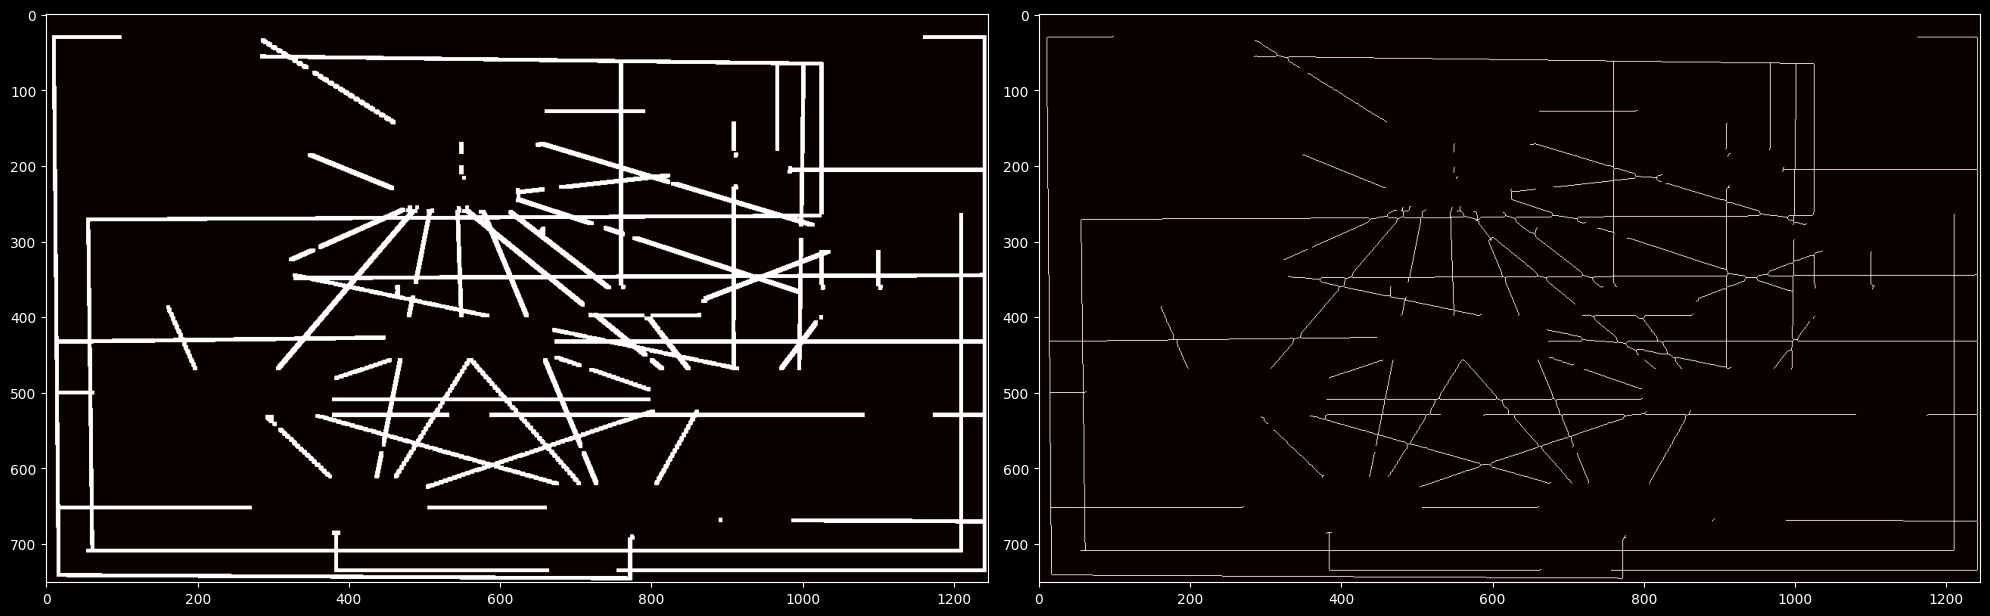

In [12]:
from skimage.morphology import skeletonize

sz = 2
element = cv2.getStructuringElement(cv2.MORPH_RECT, (2 * sz + 1, 2 * sz + 1), (sz, sz))
dst = cv2.dilate(im_clr, element)
dsts = skeletonize(dst).astype('uint8')

vic(dst, dsts)

In [13]:

from sklearn.cluster import DBSCAN

box_kernel = np.array([[1, 1, 1],
                       [1, 0, 1],
                       [1, 1, 1]], dtype=np.uint8)


def pts_from_mask(mask):
    return np.column_stack(np.where(mask > 0))[:, [1, 0]]


def detect_junctions(sk, selector=lambda i_sk, i_cnt: (i_cnt >= 3) & (i_sk == 1)):
    nb_cnt = cv2.filter2D(sk, -1, box_kernel)
    return pts_from_mask(selector(sk, nb_cnt))


def cluster_junctions(j_coord: np.ndarray, eps):
    dbs = DBSCAN(eps=eps, min_samples=1).fit(j_coord)
    res = []
    for i in set(dbs.labels_):
        pts = j_coord[dbs.labels_ == i]
        std = np.linalg.norm(pts.std(axis=0))
        cr = pts.mean(axis=0).astype(int)
        res.append((cr, std))
    return res


dsts_sep = dsts.copy()
j = detect_junctions(dsts)

for i in j:
    x, y = i
    dsts_sep[y, x] = 0

In [14]:
from collections import deque

search_directions = [
    (-1, -1), (-1, 0), (-1, 1),
    (0, -1), (0, 1),
    (1, -1), (1, 0), (1, 1)
]

def flood_ordered_inplace(image: np.ndarray, start_point):
    if not image[start_point]:
        return []
    result = [start_point]
    image[start_point] = 0
    queue = deque([(*start_point, 0, 0)])
    while queue:
        r, c, dr, dc = queue.popleft()
        for d_row, d_col in search_directions:
            new_r, new_c = r + d_row, c + d_col
            if not (0 <= new_r < image.shape[0] and 0 <= new_c < image.shape[1]):
                continue
            if image[new_r, new_c]:
                result.append((new_r, new_c))
                image[new_r, new_c] = 0
                queue.append((new_r, new_c, d_row, d_col))
    return np.array(result)


[flood]: #576 time=0.094±0.232ms total=54.2ms
[rdp]: #181 time=1.848±3.943ms total=334.4ms


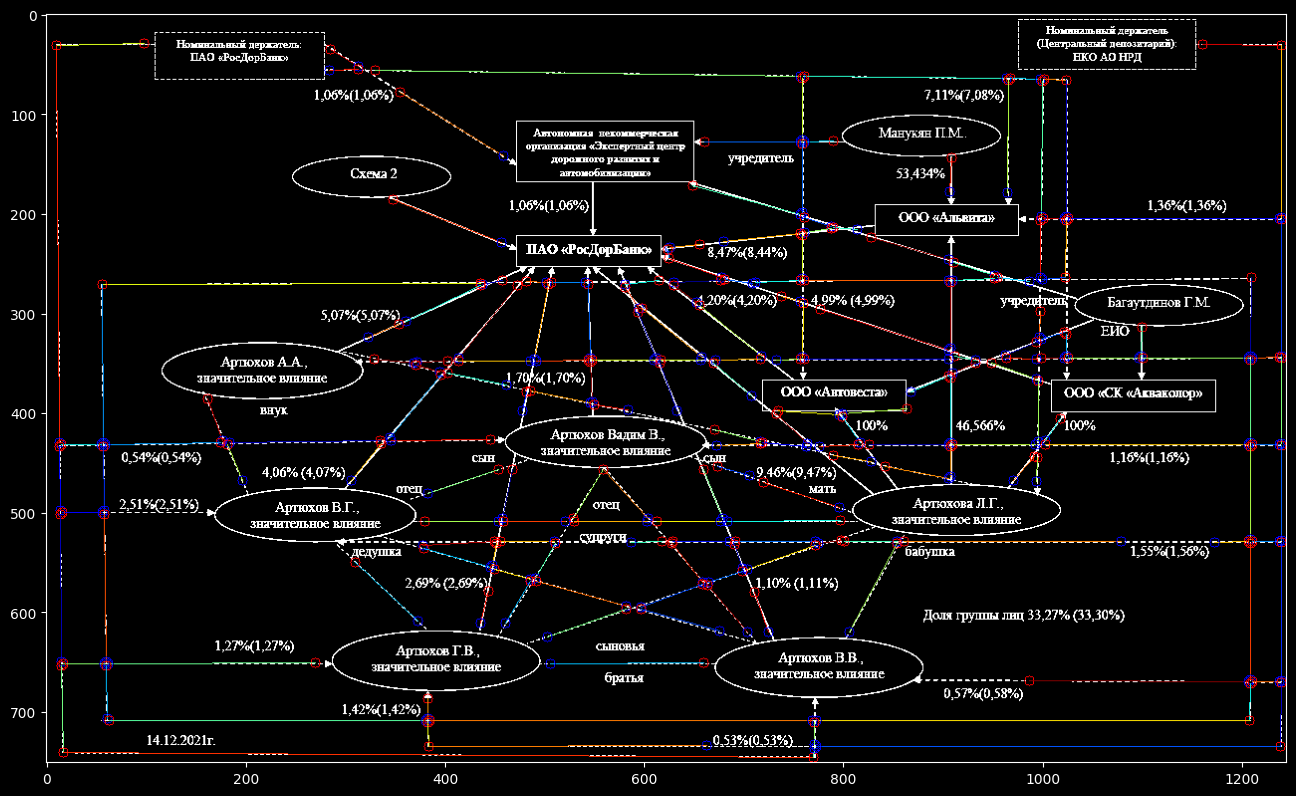

In [15]:
from utils.func import stat
from shapely import LineString
from utils.gui import vis_ls
from rdp import rdp

# sk_comps_n, sk_comps = cv2.connectedComponents(dsts_sep, connectivity=8)
sk_ends = detect_junctions(dsts_sep, lambda i_sk, i_cnt: (i_cnt == 1) & (i_sk == 1))

input_segments: List[LineString] = []
in_seg_pts = []

flood_skel = dsts_sep.copy()

min_comp_size = 20
with stat() as M:
    for ep in sk_ends:
        with M("flood"):
            pts = flood_ordered_inplace(flood_skel, tuple(ep[::-1]))
        if len(pts) < min_comp_size:
            continue
        with M("rdp"):
            segmented = rdp(pts, epsilon=5)[:, [1, 0]]

        for i in zip(segmented, segmented[1:]):
            in_seg_pts.append([Point(j) for j in i])
            input_segments.append(LineString(i))

vis(vis_ls(it, input_segments))

In [17]:
from utils.gui import vis_arrow, color_range_01, vis_circ
from visual.analyze.linegraph import LineGraph, score_partial
from visual.analyze.linegraph import GEdge
from utils.geom import m_angle
from math import radians
from utils.geom import seg_pts
import numpy as np
from shapely import Point, STRtree

def scorer_ad(own_seg: GEdge, next_seg: GEdge, distance: Tuple[float, float], angle: Tuple[float, float]):
    # ep_next_b <- [ep_next_a] & [ep_own_a] -> ep_own_b
    ep_own_a, ep_own_b = own_seg.pts
    ep_next_a, ep_next_b = next_seg.pts
    conn_dist = ep_next_a.distance(ep_own_a)
    diff_angle = abs(m_angle(own_seg.pts[::-1], next_seg.pts))
    scores = np.array([
        # score_partial(conn_dist, *distance),
        score_partial(diff_angle, *angle),
    ])
    return float(np.linalg.norm(scores) ** 2)

def make_step1_scr(im_shape):
    d = max(im_shape) * 0.2
    return lambda a,b: scorer_ad(a, b, distance=(0, d), angle=(0, radians(20)))

def make_step2_score_terminal_segments(im_shape):
    d = max(im_shape) * 0.1
    return lambda a,b: scorer_ad(a, b, distance=(0, d), angle=(0, radians(45)))

def make_step3_scr(im_shape):
    d = max(im_shape) * 0.1
    return lambda a,b: scorer_ad(a, b, distance=(0, 10), angle=(0, radians(120)))



lg = LineGraph()
lg.add_segments(in_seg_pts)
lg.add_objects(nodes)
lg.add_arrowheads(arrowheads)
lg.add_texts(ocr_data)
lg.recalc()

lg.connect_softly(make_step1_scr(orig.shape), search_radius=20)
lg.connect_terminals(make_step2_score_terminal_segments(orig.shape), max_dist=50)
# lg.connect_softly(make_step3_scr(orig.shape))

# vis(lg.vis(np.zeros_like(it)))
vis(lg.vis(it))

SyntaxError: invalid syntax (linegraph.py, line 139)

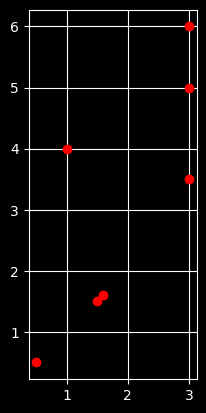

In [19]:
from math import sqrt
from matplotlib import pyplot as plt
from shapely.plotting import plot_polygon, plot_points
from shapely import box

boxes = [
    box(0, 0, 1, 1),
    box(2, 2, 5, 3),
    box(0, 5, 5, 7)
]

tests = [
    Point(0.5, 0.5),
    Point(1.5, 1.5),
    Point(1.6, 1.6),
    Point(3, 3.5),
    Point(1, 4),
    Point(3, 5),
    Point(3, 6),
]

# for i in boxes:
#     plot_polygon(i)
plot_points(tests, color='r')
plt.show()

# st = STRtree(tests)
# for i in boxes:
#     print(st.query(i, predicate="dwithin", distance=0.00000001))

In [39]:
# to_process = [i.uid for i in lg.unbound_nodes()]
# dn = False
# for nid in to_process:
#     node = lg.node(nid)
#     if node.typ != NType.UNBOUND: continue
#     if (proposal := lg.propose_for_node(nid)) is None: continue
#     cur_edge, proposed_edges = proposal
#
#     variants = rank_pairs(join_score_step1, cur_edge, proposed_edges, max_score=1)
#     if len(variants) == 0: continue
#
#     col = color_range_01()
#     score, other_edge = variants[0]
#     lg.connect(cur_edge.u_start, other_edge.u_start, CType.SOFT, NType.BOUND_INT)
#
#     # print(score, cur_edge, other_edge)
#     # pt_as, pt_ae = [i.uid for i in cur_edge.nds]
#     # pt_bs, pt_be = [i.uid for i in other_edge.nds]
#     # vis_arrow(vislg, cur_edge.nds[0].pt, cur_edge.nds[1].pt, col)
#     # vis_arrow(vislg, other_edge.nds[0].pt, other_edge.nds[1].pt, col)
#     # lg.mark_node(pt_as, NType.BOUND_INT)
#     # lg.mark_node(pt_bs, NType.BOUND_INT)
#     # lg.mark_node(pt_bs, NType.BOUND_START)
#     # lg.mark_node(pt_be, NType.BOUND_INT)
#
# # vis(vislg)
# # vis(lg.vis(dst))